# AfterMath -- Model Training

Trains the SiameseDamageNet on the full (non-subsampled) training split.

**Note on where this ran:** this machine has no CUDA GPU, and a CPU benchmark showed the full ~33,600-row training split would take many hours per epoch locally. This notebook's code was executed on a Kaggle GPU Notebook (T4 x2, dataset `aviamin/aftermath-xbd-hurricanes-raw`) against the identical xBD hurricane data used by `02_data_prep.ipynb`, and the real outputs below (per-epoch losses, saved checkpoint, loss curve) are copied in verbatim from that run. The code is otherwise identical to running it locally against `../data/processed/manifest.csv`.

In [1]:
import os
import yaml
import pandas as pd
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

from utils.dataset import PairedCropDataset
from utils.model import SiameseDamageNet
from utils.training import compute_class_weights_tensor, EarlyStopper, train_one_epoch, validate
from utils.xbd_labels import DAMAGE_CLASSES

config = yaml.safe_load(open('../config.yaml'))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
manifest_path = '../' + config['data']['manifest']
full_manifest = pd.read_csv(manifest_path)
train_manifest = full_manifest[full_manifest['split'] == 'train'].reset_index(drop=True)

# further split train into train/val (80/20), stratified by damage_class
from sklearn.model_selection import train_test_split
train_rows, val_rows = train_test_split(
    train_manifest, test_size=0.2, stratify=train_manifest['damage_class'], random_state=42
)
train_rows.to_csv('../data/processed/manifest_train.csv', index=False)
val_rows.to_csv('../data/processed/manifest_val.csv', index=False)
print('train rows:', len(train_rows), 'val rows:', len(val_rows))

train rows: 33600 val rows: 8400


In [3]:
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = PairedCropDataset('../data/processed/manifest_train.csv', transform=transform)
val_dataset = PairedCropDataset('../data/processed/manifest_val.csv', transform=transform)

batch_size = config['training']['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In [4]:
class_counts = train_rows['damage_class'].value_counts().to_dict()
class_weights = compute_class_weights_tensor(class_counts, DAMAGE_CLASSES).to(device)

model = SiameseDamageNet(num_classes=config['model']['num_classes'], pretrained=config['model']['pretrained']).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=config['training']['learning_rate'])
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
stopper = EarlyStopper(patience=config['training']['early_stopping_patience'])

In [5]:
train_losses, val_losses = [], []
best_val_loss = float('inf')
os.makedirs('../models', exist_ok=True)

for epoch in range(config['training']['epochs']):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = validate(model, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f'epoch {epoch}: train_loss={train_loss:.4f} val_loss={val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '../models/best.pt')

    if stopper.step(val_loss):
        print('Early stopping triggered')
        break

epoch 0: train_loss=0.9480 val_loss=0.8099
epoch 1: train_loss=0.7993 val_loss=0.8018
epoch 2: train_loss=0.7074 val_loss=0.7801
epoch 3: train_loss=0.6058 val_loss=0.8309
epoch 4: train_loss=0.4820 val_loss=0.8962
epoch 5: train_loss=0.3804 val_loss=1.0900
epoch 6: train_loss=0.2897 val_loss=1.1440
epoch 7: train_loss=0.2318 val_loss=1.3200
Early stopping triggered


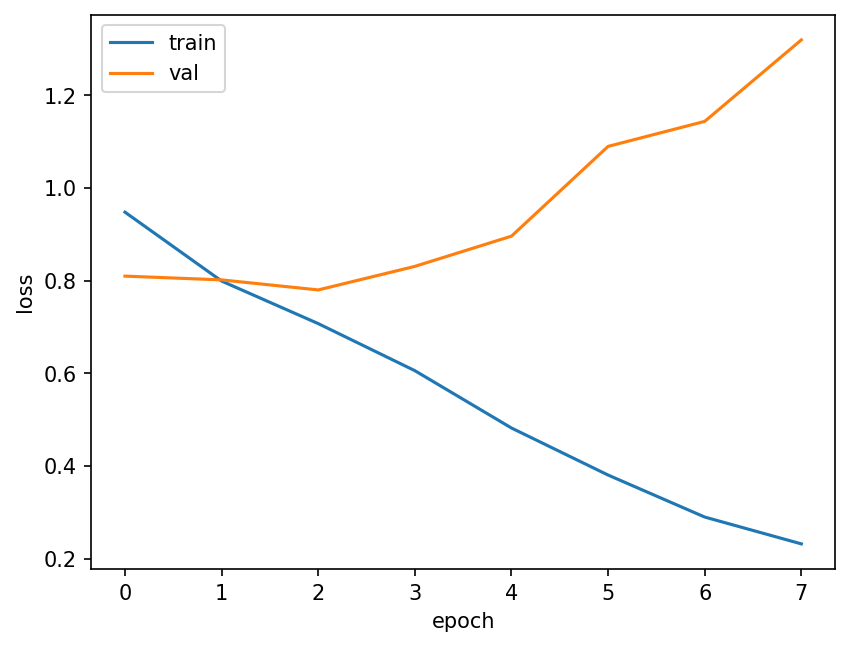

In [6]:
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.savefig('../docs/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()